In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform
import os
import sys
import time as _time

sys.path.append(os.path.abspath("../../repos/RiskLabAI.py"))
from src.quantum_hrp import compute_financial_features, fetch_stock_data, average_density_matrix, compute_distance_matrix, quantum_ordering, classical_hrp_ordering, simulate_asset_features_regimes


In [2]:
returns = pd.read_csv("../../data/returns.csv", index_col=0, parse_dates=True)
features = np.load("../../data/features.npy")

# Comprobaciones básicas
print(returns.shape)   # (T, N)
print(features.shape)  # (N, T, P)


(1147, 169)
(169, 1147, 6)


In [3]:


prices = pd.read_parquet("../../data/prices.parquet")
volumes = pd.read_parquet("../../data/volumes.parquet")

print("prices range:", prices.index.min(), prices.index.max(), "shape:", prices.shape)
print("volumes range:", volumes.index.min(), volumes.index.max(), "shape:", volumes.shape)

prices range: 2005-01-03 00:00:00 2024-12-31 00:00:00 shape: (6202, 169)
volumes range: 2005-01-03 00:00:00 2024-12-31 00:00:00 shape: (6202, 169)


In [4]:
# Guardar el orden original de columnas para mapear features → returns
original_columns = returns.columns.tolist()

returns = returns.apply(pd.to_numeric, errors="coerce")
returns = returns.dropna(axis=0, how="any")
returns = returns.dropna(axis=1, how="all")

# Eliminar activos casi constantes (evitar NaN/correlaciones inestables)
std = returns.std(axis=0)
returns = returns.loc[:, std > 1e-8]
print("returns shape tras limpieza:", returns.shape)
if returns.shape[1] < 2:
    raise ValueError("No hay suficientes activos tras limpiar returns. Revisar la generación de returns.csv.")

# Sincronizar features con las columnas supervivientes en returns
surviving_idx = [original_columns.index(c) for c in returns.columns]
features = features[surviving_idx]
print("features shape tras sincronización:", features.shape)

R = returns.values
corr = np.corrcoef(R, rowvar=False)
print(f"Corr shape: {corr.shape} | rango: [{corr[np.triu_indices_from(corr,1)].min():.3f}, {corr[np.triu_indices_from(corr,1)].max():.3f}]")


returns shape tras limpieza: (1147, 169)
features shape tras sincronización: (169, 1147, 6)
Corr shape: (169, 169) | rango: [-0.185, 1.000]


In [5]:
def frobenius_distance(rho1, rho2, scale=1.5):
    """
    Calcula la distancia de Frobenius escalada entre dos matrices de densidad.
    Coincide con el repositorio del paper: scale=1.5 (por defecto).
    """
    diff = rho1 - rho2
    return scale * (0.5 * np.sqrt(np.trace(diff.conj().T @ diff)))

def compute_distance_matrix_paper(rho_list):
    """
    Calcula una matriz de distancias a partir de una lista de matrices de densidad
    usando la frobenius_distance del paper (scale=1.5).
    """
    N = len(rho_list)
    D = np.zeros((N, N))
    for i in range(N):
        for j in range(i + 1, N):
            d = frobenius_distance(rho_list[i], rho_list[j])
            D[i, j] = d
            D[j, i] = d
    return D


In [6]:
def quasi_diagonal(linkage_matrix):
    """
    Cuasi-diagonalización de la matriz de enlace (igual que en el repositorio del paper).
    Devuelve una lista ordenada de los índices originales.
    """
    linkage_matrix = linkage_matrix.astype(int)
    sorted_items = pd.Series([linkage_matrix[-1, 0], linkage_matrix[-1, 1]])
    num_items = linkage_matrix[-1, 3]

    while sorted_items.max() >= num_items:
        sorted_items.index = range(0, sorted_items.shape[0] * 2, 2)
        dataframe = sorted_items[sorted_items >= num_items]
        i = dataframe.index
        j = dataframe.values - num_items
        sorted_items[i] = linkage_matrix[j, 0]
        dataframe = pd.Series(linkage_matrix[j, 1], index=i + 1)
        sorted_items = sorted_items._append(dataframe)
        sorted_items = sorted_items.sort_index()
        sorted_items.index = range(sorted_items.shape[0])
    return sorted_items.tolist()

# Ordenación HRP clásica: correlación → distancia → enlace simple → quasi_diagonal
dist_classical = np.sqrt((1 - corr) / 2.0)
dist_classical = 0.5 * (dist_classical + dist_classical.T)
np.fill_diagonal(dist_classical, 0.0)
dist_classical = np.nan_to_num(dist_classical)

link_classical = linkage(squareform(dist_classical), method="single")
order_classical = quasi_diagonal(link_classical)
order_classical = [int(x) for x in order_classical]

corr_classical = corr[np.ix_(order_classical, order_classical)]


In [7]:
alpha = 2.0

# Ventana temporal (~3 años de días de negociación)
T_window = 756
window = slice(-T_window, None)

# P=6 features definidas en compute_financial_features(window=5) del paper:
# f1=retorno, f2=media móvil, f3=desv. estándar móvil, f4=retorno acumulado, f5=asimetría, f6=curtosis
N = returns.shape[1]
T_total = returns.shape[0]
P = 6
features_p6 = np.zeros((N, T_total, P))
from scipy import stats as sp_stats
for j in range(N):
    s = R[:, j]
    for t in range(T_total):
        st = max(0, t - 4)
        w = s[st:t+1]
        features_p6[j, t, 0] = s[t]                                            # retorno diario
        features_p6[j, t, 1] = np.mean(w)                                      # media móvil
        features_p6[j, t, 2] = np.std(w, ddof=1) if len(w) > 1 else 0.0       # desv. estándar móvil
        features_p6[j, t, 3] = np.prod(1 + w) - 1                              # retorno acumulado
        features_p6[j, t, 4] = sp_stats.skew(w) if len(w) > 2 else 0.0        # asimetría
        features_p6[j, t, 5] = sp_stats.kurtosis(w) if len(w) > 3 else 0.0    # curtosis

rho_list = []
for i in range(N):
    rho_i = average_density_matrix(
        features_p6[i][window],  # (T_window, 6)
        alpha
    )
    rho_list.append(rho_i)

# Usar la distancia del paper (scale=1.5)
D_quantum = compute_distance_matrix_paper(rho_list)
print(f"D_quantum rango: [{D_quantum.min():.4f}, {D_quantum.max():.4f}]")


D_quantum rango: [0.0000, 0.3455]


In [8]:
def quantum_ordering_ward(D):
    """
    Ordenación QHRP usando enlace de Ward,
    reproduciendo la función quantum_ordering del paper.
    """
    condensed_D = squareform(D)
    Z = linkage(condensed_D, method="ward")
    order = leaves_list(Z)
    return order


In [9]:
# Ordenación cuántica con enlace de Ward (método del paper)
order_quantum = quantum_ordering_ward(D_quantum)
D_quantum_ordered = D_quantum[np.ix_(order_quantum, order_quantum)]

corr_quantum = corr[np.ix_(order_quantum, order_quantum)]


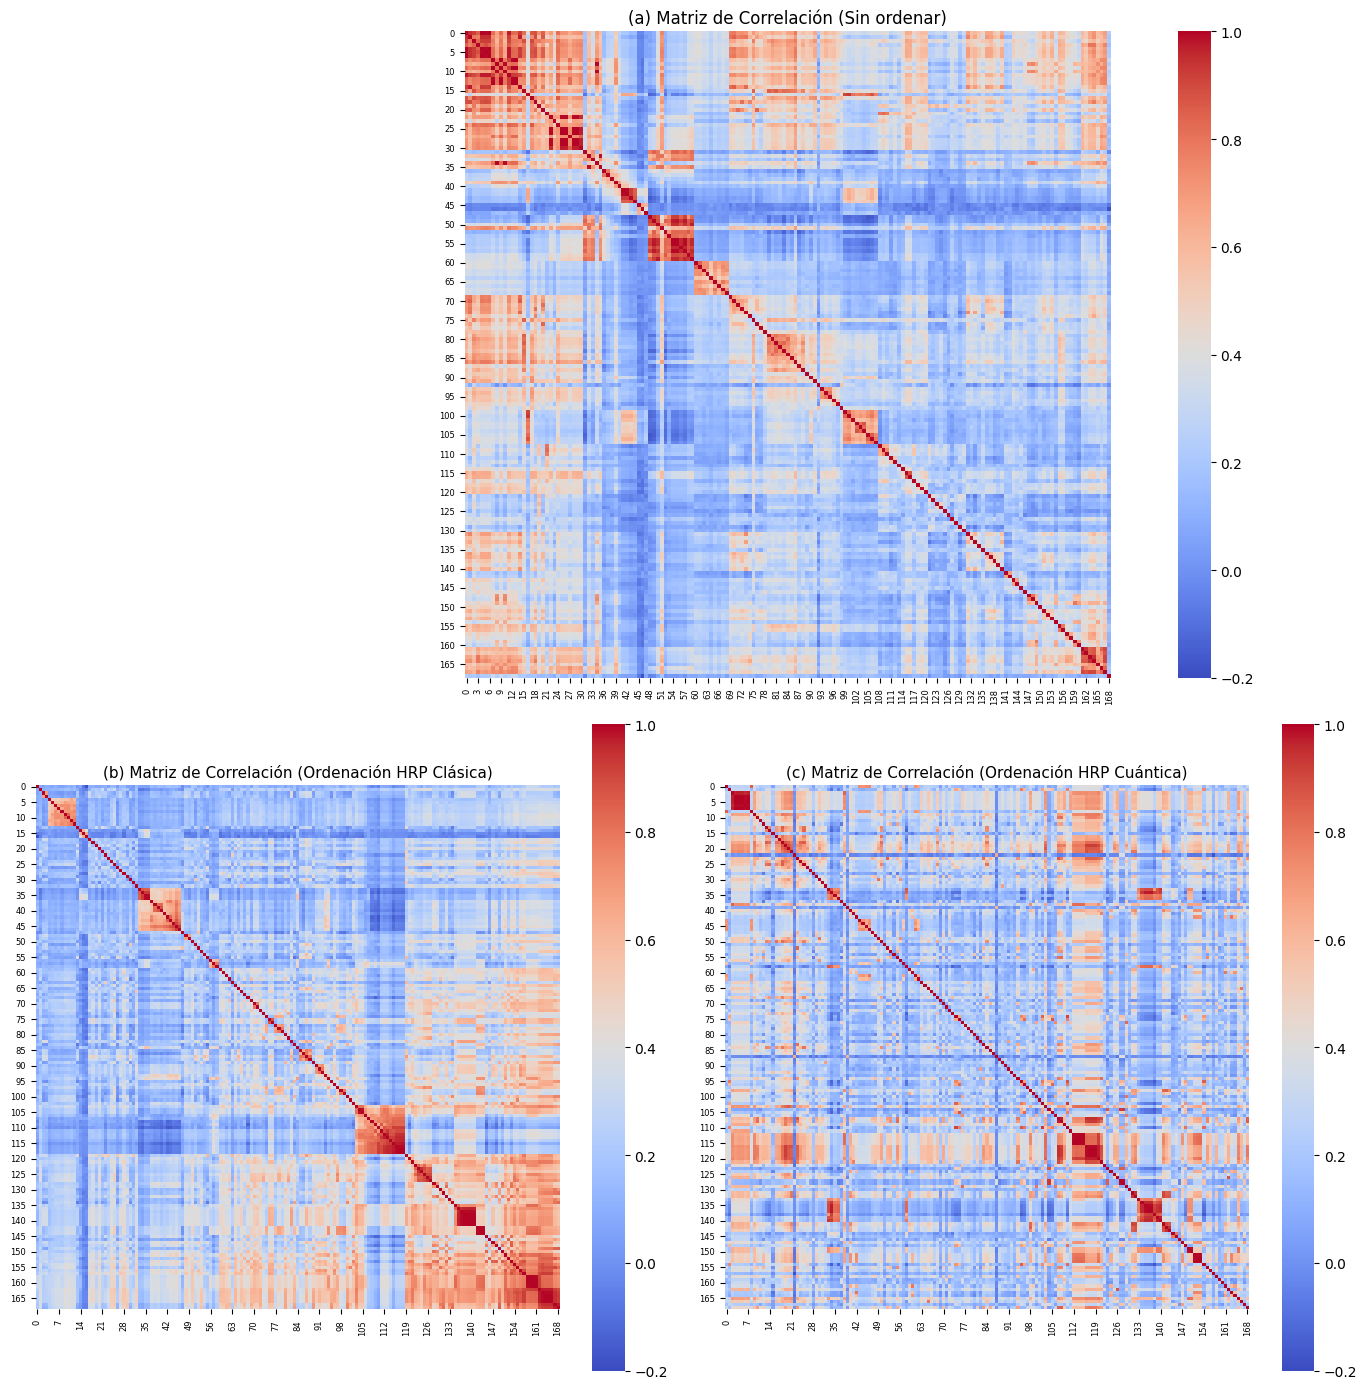

In [10]:
out_dir = os.path.abspath("../../latex/img")
os.makedirs(out_dir, exist_ok=True)

fig = plt.figure(figsize=(14, 14))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1])

# ---------- (a) Sin ordenar ----------
ax0 = fig.add_subplot(gs[0, :])
sns.heatmap(
    corr,
    cmap="coolwarm",
    vmin=-0.2,
    vmax=1.0,
    square=True,
    cbar=True,
    ax=ax0
)
ax0.set_title("(a) Matriz de Correlación (Sin ordenar)", fontsize=12)
ax0.tick_params(labelsize=6)

# ---------- (b) HRP Clásico ----------
ax1 = fig.add_subplot(gs[1, 0])
sns.heatmap(
    corr_classical,
    cmap="coolwarm",
    vmin=-0.2,
    vmax=1.0,
    square=True,
    cbar=True,
    ax=ax1
)
ax1.set_title("(b) Matriz de Correlación (Ordenación HRP Clásica)", fontsize=11)
ax1.tick_params(labelsize=6)

# ---------- (c) HRP Cuántico ----------
ax2 = fig.add_subplot(gs[1, 1])
sns.heatmap(
    corr_quantum,
    cmap="coolwarm",
    vmin=-0.2,
    vmax=1.0,
    square=True,
    cbar=True,
    ax=ax2
)
ax2.set_title("(c) Matriz de Correlación (Ordenación HRP Cuántica)", fontsize=11)
ax2.tick_params(labelsize=6)

plt.tight_layout()
fig.savefig(os.path.join(out_dir, "fig3-corr-matrices.png"), dpi=300, bbox_inches="tight")
fig.savefig(os.path.join(out_dir, "fig3-corr-matrices.pdf"), bbox_inches="tight")
fig.savefig(os.path.join(out_dir, "fig3-corr-matrices.jpg"), dpi=300, bbox_inches="tight")
plt.show()


## Características antiguas de "transformación matemática" (código muerto en el repositorio)

La función `fetch_stock_data` del repositorio del autor tiene **dos** bloques de características — el primero usa transformaciones matemáticas de un solo retorno (sin ventana móvil), y el segundo (actualmente activo) lo sobrescribe con `compute_financial_features` (ventana móvil). Las mismas características antiguas aparecen comentadas en `simulate_asset_features_regimes`.

**Características antiguas** (puntuales, sin ventana móvil):
| # | Característica | Fórmula |
|---|---|---|
| f0 | retorno | r |
| f1 | retorno al cuadrado | r² |
| f2 | transformación potencial | \|r\|^1.5 |
| f3 | logaritmo con signo | sign(r) · log(1+\|r\|) |
| f4 | tanh | tanh(r) |
| f5 | raíz cuadrada con signo | sign(r) · √(\|r\|) |

A continuación probamos si la Figura 4 del paper se generó con estas características antiguas.

In [11]:
# ── Features antiguas de "transformación matemática" (código muerto del repositorio del autor) ──
# Son transformaciones por valor de retorno (SIN ventana móvil):
#   f0 = r,  f1 = r²,  f2 = |r|^1.5,  f3 = sign(r)·log(1+|r|),
#   f4 = tanh(r),  f5 = sign(r)·√(|r|+1e-6)

features_old = np.zeros((N, T_total, 6))
for j in range(N):
    for t in range(T_total):
        r = R[t, j]
        features_old[j, t, 0] = r                                              # retorno bruto (señal lineal)
        features_old[j, t, 1] = r ** 2                                         # retorno al cuadrado (proxy de volatilidad)
        features_old[j, t, 2] = abs(r) ** 1.5                                  # transformación potencial (enfatiza movimientos grandes)
        features_old[j, t, 3] = np.log1p(abs(r)) * np.sign(r)                  # logaritmo con signo (comprime colas, mantiene signo)
        features_old[j, t, 4] = np.tanh(r)                                     # tanh (acotada ≈ recorte suave a [-1,1])
        features_old[j, t, 5] = np.sign(r) * np.sqrt(abs(r) + 1e-6)           # raíz con signo (amplifica movimientos pequeños)

# Calcular matriz de distancias para cada P con features ANTIGUAS
D_old_per_p = {}
for p in range(1, 7):
    t0 = _time.time()
    feats = features_old[:, :, :p]

    rho_list_old = []
    for i in range(N):
        rho_i = average_density_matrix(feats[i][window], alpha)
        rho_list_old.append(rho_i)

    D_old = compute_distance_matrix_paper(rho_list_old)
    D_old_per_p[p] = D_old

    off = D_old[np.triu_indices_from(D_old, 1)]
    elapsed = _time.time() - t0
    print(f"ANTIGUAS P={p}  rango: [{off.min():.4f}, {off.max():.4f}]  "
          f"densidad: {rho_list_old[0].shape}  tiempo: {elapsed:.1f}s")

# Calcular matriz de distancias para cada P con features NUEVAS (compute_financial_features)
print("\n--- Features NUEVAS (ventana móvil) ---")
D_per_p = {}
for p in range(1, 7):
    t0 = _time.time()
    feats = features_p6[:, :, :p]

    rho_list_new = []
    for i in range(N):
        rho_i = average_density_matrix(feats[i][window], alpha)
        rho_list_new.append(rho_i)

    D_new = compute_distance_matrix_paper(rho_list_new)
    D_per_p[p] = D_new

    off = D_new[np.triu_indices_from(D_new, 1)]
    elapsed = _time.time() - t0
    print(f"NUEVAS P={p}  rango: [{off.min():.4f}, {off.max():.4f}]  "
          f"densidad: {rho_list_new[0].shape}  tiempo: {elapsed:.1f}s")


ANTIGUAS P=1  rango: [0.0016, 0.9110]  densidad: (2, 2)  tiempo: 203.5s
ANTIGUAS P=2  rango: [0.0027, 0.9214]  densidad: (4, 4)  tiempo: 371.4s
ANTIGUAS P=3  rango: [0.0033, 1.0154]  densidad: (8, 8)  tiempo: 529.0s
ANTIGUAS P=4  rango: [0.0041, 0.9518]  densidad: (16, 16)  tiempo: 686.6s
ANTIGUAS P=5  rango: [0.0048, 0.9475]  densidad: (32, 32)  tiempo: 880.3s
ANTIGUAS P=6  rango: [0.0050, 0.8474]  densidad: (64, 64)  tiempo: 1062.9s

--- Features NUEVAS (ventana móvil) ---
NUEVAS P=1  rango: [0.0016, 0.9110]  densidad: (2, 2)  tiempo: 201.1s
NUEVAS P=2  rango: [0.0036, 0.8493]  densidad: (4, 4)  tiempo: 366.1s
NUEVAS P=3  rango: [0.0059, 0.8313]  densidad: (8, 8)  tiempo: 525.3s
NUEVAS P=4  rango: [0.0074, 0.7968]  densidad: (16, 16)  tiempo: 688.9s
NUEVAS P=5  rango: [0.0074, 0.5188]  densidad: (32, 32)  tiempo: 889.3s
NUEVAS P=6  rango: [0.0094, 0.3455]  densidad: (64, 64)  tiempo: 1060.9s


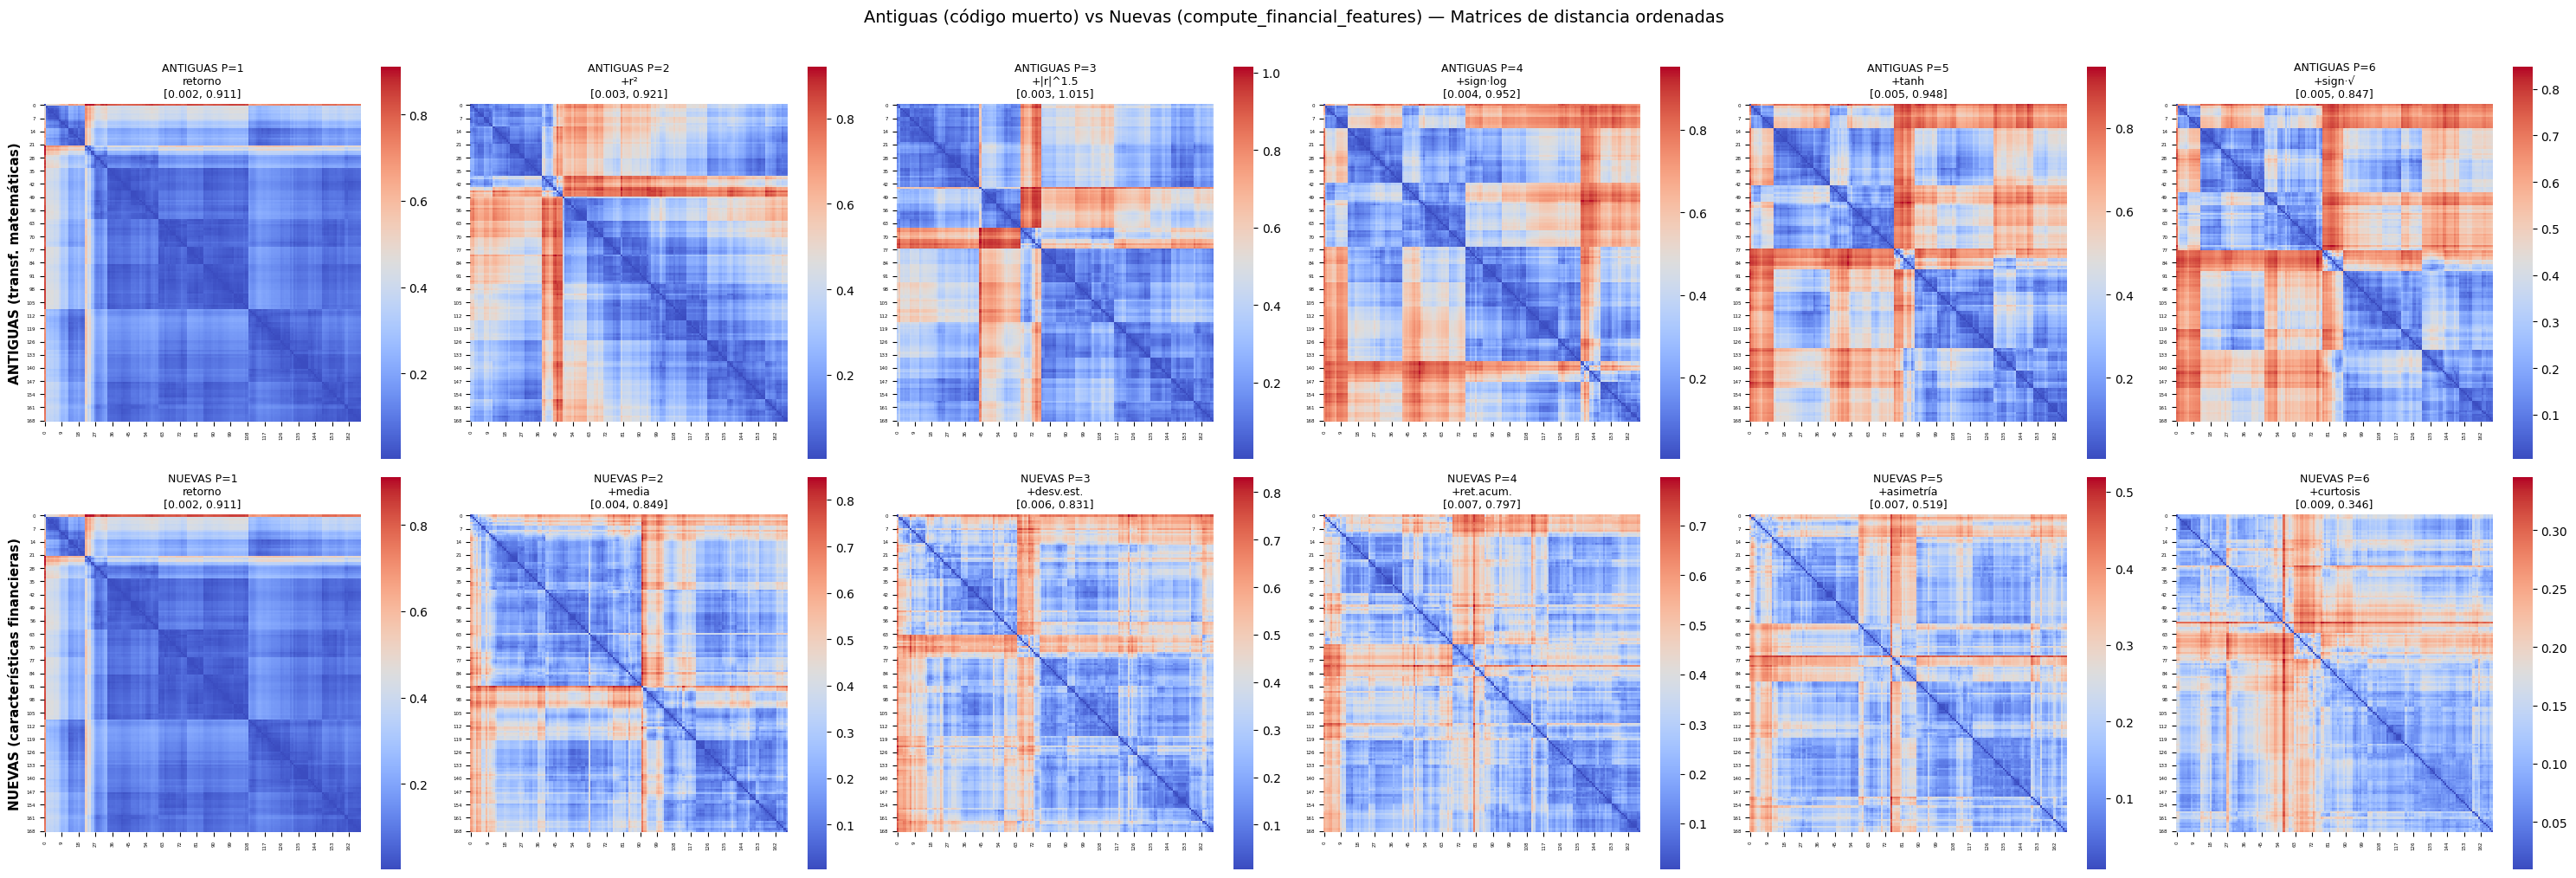

In [12]:
# ── Comparación lado a lado: features ANTIGUAS vs NUEVAS para cada P ──────
fig, axes = plt.subplots(2, 6, figsize=(30, 10))

feature_labels_new = ["retorno", "+media", "+desv.est.", "+ret.acum.", "+asimetría", "+curtosis"]
feature_labels_old = ["retorno", "+r²", "+|r|^1.5", "+sign·log", "+tanh", "+sign·√"]

for col, p in enumerate(range(1, 7)):
    # Features ANTIGUAS
    D_old = D_old_per_p[p]
    order_old = quantum_ordering_ward(D_old)
    D_old_ord = D_old[np.ix_(order_old, order_old)]
    off_old = D_old[np.triu_indices_from(D_old, 1)]

    sns.heatmap(
        D_old_ord, cmap="coolwarm",
        vmin=off_old.min(), vmax=off_old.max(),
        square=True, cbar=True, ax=axes[0, col],
    )
    axes[0, col].set_title(
        f"ANTIGUAS P={p}\n{feature_labels_old[col]}\n[{off_old.min():.3f}, {off_old.max():.3f}]",
        fontsize=9
    )
    axes[0, col].tick_params(labelsize=4)

    # Features NUEVAS (compute_financial_features)
    D_new = D_per_p[p]
    order_new = quantum_ordering_ward(D_new)
    D_new_ord = D_new[np.ix_(order_new, order_new)]
    off_new = D_new[np.triu_indices_from(D_new, 1)]

    sns.heatmap(
        D_new_ord, cmap="coolwarm",
        vmin=off_new.min(), vmax=off_new.max(),
        square=True, cbar=True, ax=axes[1, col],
    )
    axes[1, col].set_title(
        f"NUEVAS P={p}\n{feature_labels_new[col]}\n[{off_new.min():.3f}, {off_new.max():.3f}]",
        fontsize=9
    )
    axes[1, col].tick_params(labelsize=4)

axes[0, 0].set_ylabel("ANTIGUAS (transf. matemáticas)", fontsize=11, fontweight="bold")
axes[1, 0].set_ylabel("NUEVAS (características financieras)", fontsize=11, fontweight="bold")

plt.suptitle(
    "Antiguas (código muerto) vs Nuevas (compute_financial_features) — Matrices de distancia ordenadas",
    fontsize=14, y=1.01
)
plt.tight_layout()
fig.savefig(
    os.path.join(out_dir, "fig4-old-vs-new-features.png"),
    dpi=300, bbox_inches="tight"
)
plt.show()

ANTIGUAS P=6, con ventana, scale=1.0: [0.0033, 0.5649]
Usando vmax = 0.55


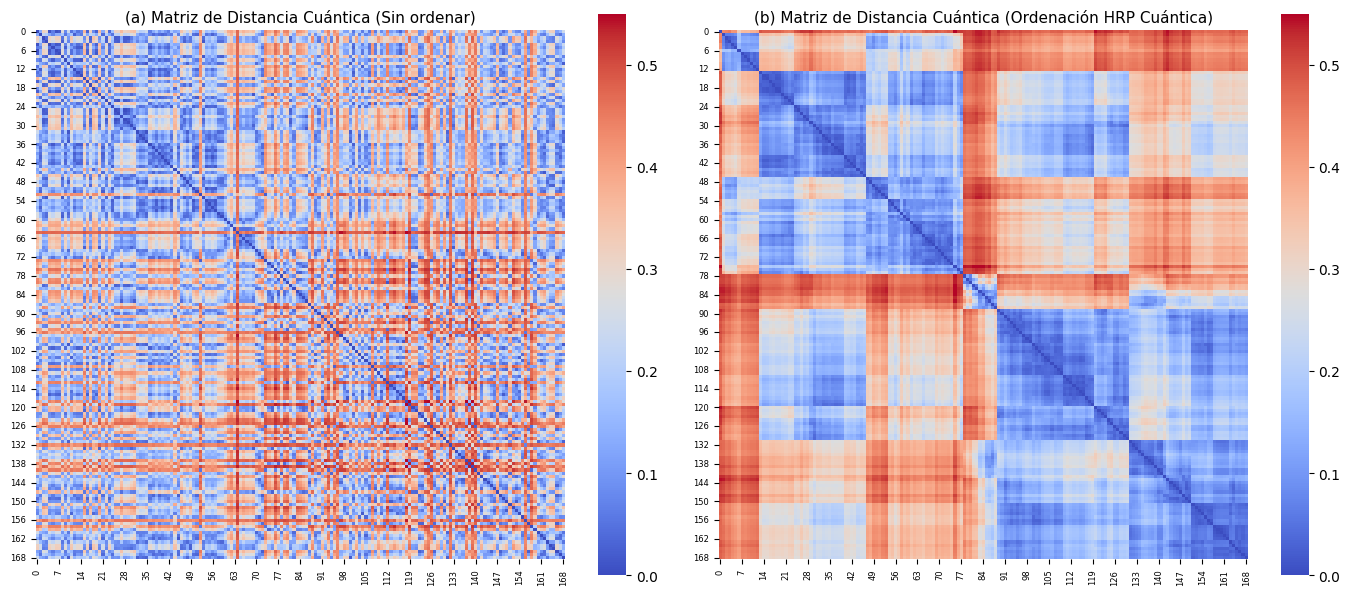

In [13]:
# ── HALLAZGO CLAVE: la fórmula de la tesis dice scale=1.0, NO 1.5 ─────────
# d_F(ρ_i, ρ_j) = ½ √Tr[(ρ_i - ρ_j)²]  (sin factor de escala)
# El código usa scale=1.5, pero la fórmula del paper tiene scale=1.0.
# Reescalando nuestras distancias existentes: D_scale1 = D_scale1.5 / 1.5

# Features ANTIGUAS P=6, con ventana, SCALE=1.0 (coincide con la fórmula de la tesis)
D_best = D_old_per_p[6] / 1.5   # convertir de scale=1.5 a scale=1.0
off_best = D_best[np.triu_indices_from(D_best, 1)]
print(f"ANTIGUAS P=6, con ventana, scale=1.0: [{off_best.min():.4f}, {off_best.max():.4f}]")

order_best = quantum_ordering_ward(D_best)
D_best_ordered = D_best[np.ix_(order_best, order_best)]

# Usar vmax ligeramente por debajo del máximo para que más valores saturen a rojo
# La barra de color del paper recorta visualmente algunos valores → bloques rojos más vívidos
vmax_fig = 0.55
print(f"Usando vmax = {vmax_fig}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(D_best, cmap="coolwarm", vmin=0, vmax=vmax_fig,
            square=True, cbar=True, ax=axes[0])
axes[0].set_title("(a) Matriz de Distancia Cuántica (Sin ordenar)", fontsize=11)
axes[0].tick_params(labelsize=6)

sns.heatmap(D_best_ordered, cmap="coolwarm", vmin=0, vmax=vmax_fig,
            square=True, cbar=True, ax=axes[1])
axes[1].set_title("(b) Matriz de Distancia Cuántica (Ordenación HRP Cuántica)", fontsize=11)
axes[1].tick_params(labelsize=6)

plt.tight_layout()
fig.savefig(os.path.join(out_dir, "fig4-best-match.png"), dpi=300, bbox_inches="tight")
fig.savefig(os.path.join(out_dir, "fig4-best-match.pdf"), bbox_inches="tight")
plt.show()


## Test de permutación: mismos datos, orden de activos aleatorio

Permutamos el orden de las columnas de los activos y recalculamos todo desde cero.
Los paneles **sin ordenar** deberían verse diferentes (píxeles reordenados), mientras que
los paneles **ordenados** (HRP clásico, HRP cuántico) deberían ser idénticos — demostrando
que el clustering es invariante a permutaciones.

In [14]:
# ── Crear una permutación aleatoria de los índices de activos ──────────────
rng = np.random.default_rng(42)
perm = rng.permutation(N)
print(f"Primeros 10 índices de la permutación: {perm[:10]}")

# Reordenar columnas de returns y features según la permutación
returns_shuf = returns.iloc[:, perm]
R_shuf = returns_shuf.values
features_old_shuf = features_old[perm]
features_p6_shuf = features_p6[perm]

# Recalcular correlación con los returns permutados
corr_shuf = np.corrcoef(R_shuf, rowvar=False)
print(f"corr_shuf shape: {corr_shuf.shape}")


Primeros 10 índices de la permutación: [152  54   7  33 125  24  56  93 120 108]
corr_shuf shape: (169, 169)


In [15]:
# ── Ordenación HRP clásica sobre datos permutados ─────────────────────────
dist_classical_shuf = np.sqrt((1 - corr_shuf) / 2.0)
dist_classical_shuf = 0.5 * (dist_classical_shuf + dist_classical_shuf.T)
np.fill_diagonal(dist_classical_shuf, 0.0)
dist_classical_shuf = np.nan_to_num(dist_classical_shuf)

link_classical_shuf = linkage(squareform(dist_classical_shuf), method="single")
order_classical_shuf = quasi_diagonal(link_classical_shuf)
order_classical_shuf = [int(x) for x in order_classical_shuf]

corr_classical_shuf = corr_shuf[np.ix_(order_classical_shuf, order_classical_shuf)]
print("Ordenación HRP clásica (permutada) calculada.")


Ordenación HRP clásica (permutada) calculada.


In [16]:
# ── Ordenación cuántica sobre datos permutados (features ANTIGUAS P=6, scale=1.0) ──
rho_list_shuf = []
for i in range(N):
    rho_i = average_density_matrix(features_old_shuf[i][window], alpha)
    rho_list_shuf.append(rho_i)

D_quantum_shuf = compute_distance_matrix_paper(rho_list_shuf) / 1.5  # scale=1.0
order_quantum_shuf = quantum_ordering_ward(D_quantum_shuf)
D_quantum_shuf_ordered = D_quantum_shuf[np.ix_(order_quantum_shuf, order_quantum_shuf)]
corr_quantum_shuf = corr_shuf[np.ix_(order_quantum_shuf, order_quantum_shuf)]

print(f"D_quantum_shuf rango: [{D_quantum_shuf.min():.4f}, {D_quantum_shuf.max():.4f}]")
print("Ordenación cuántica (permutada) calculada.")


D_quantum_shuf rango: [0.0000, 0.5649]
Ordenación cuántica (permutada) calculada.


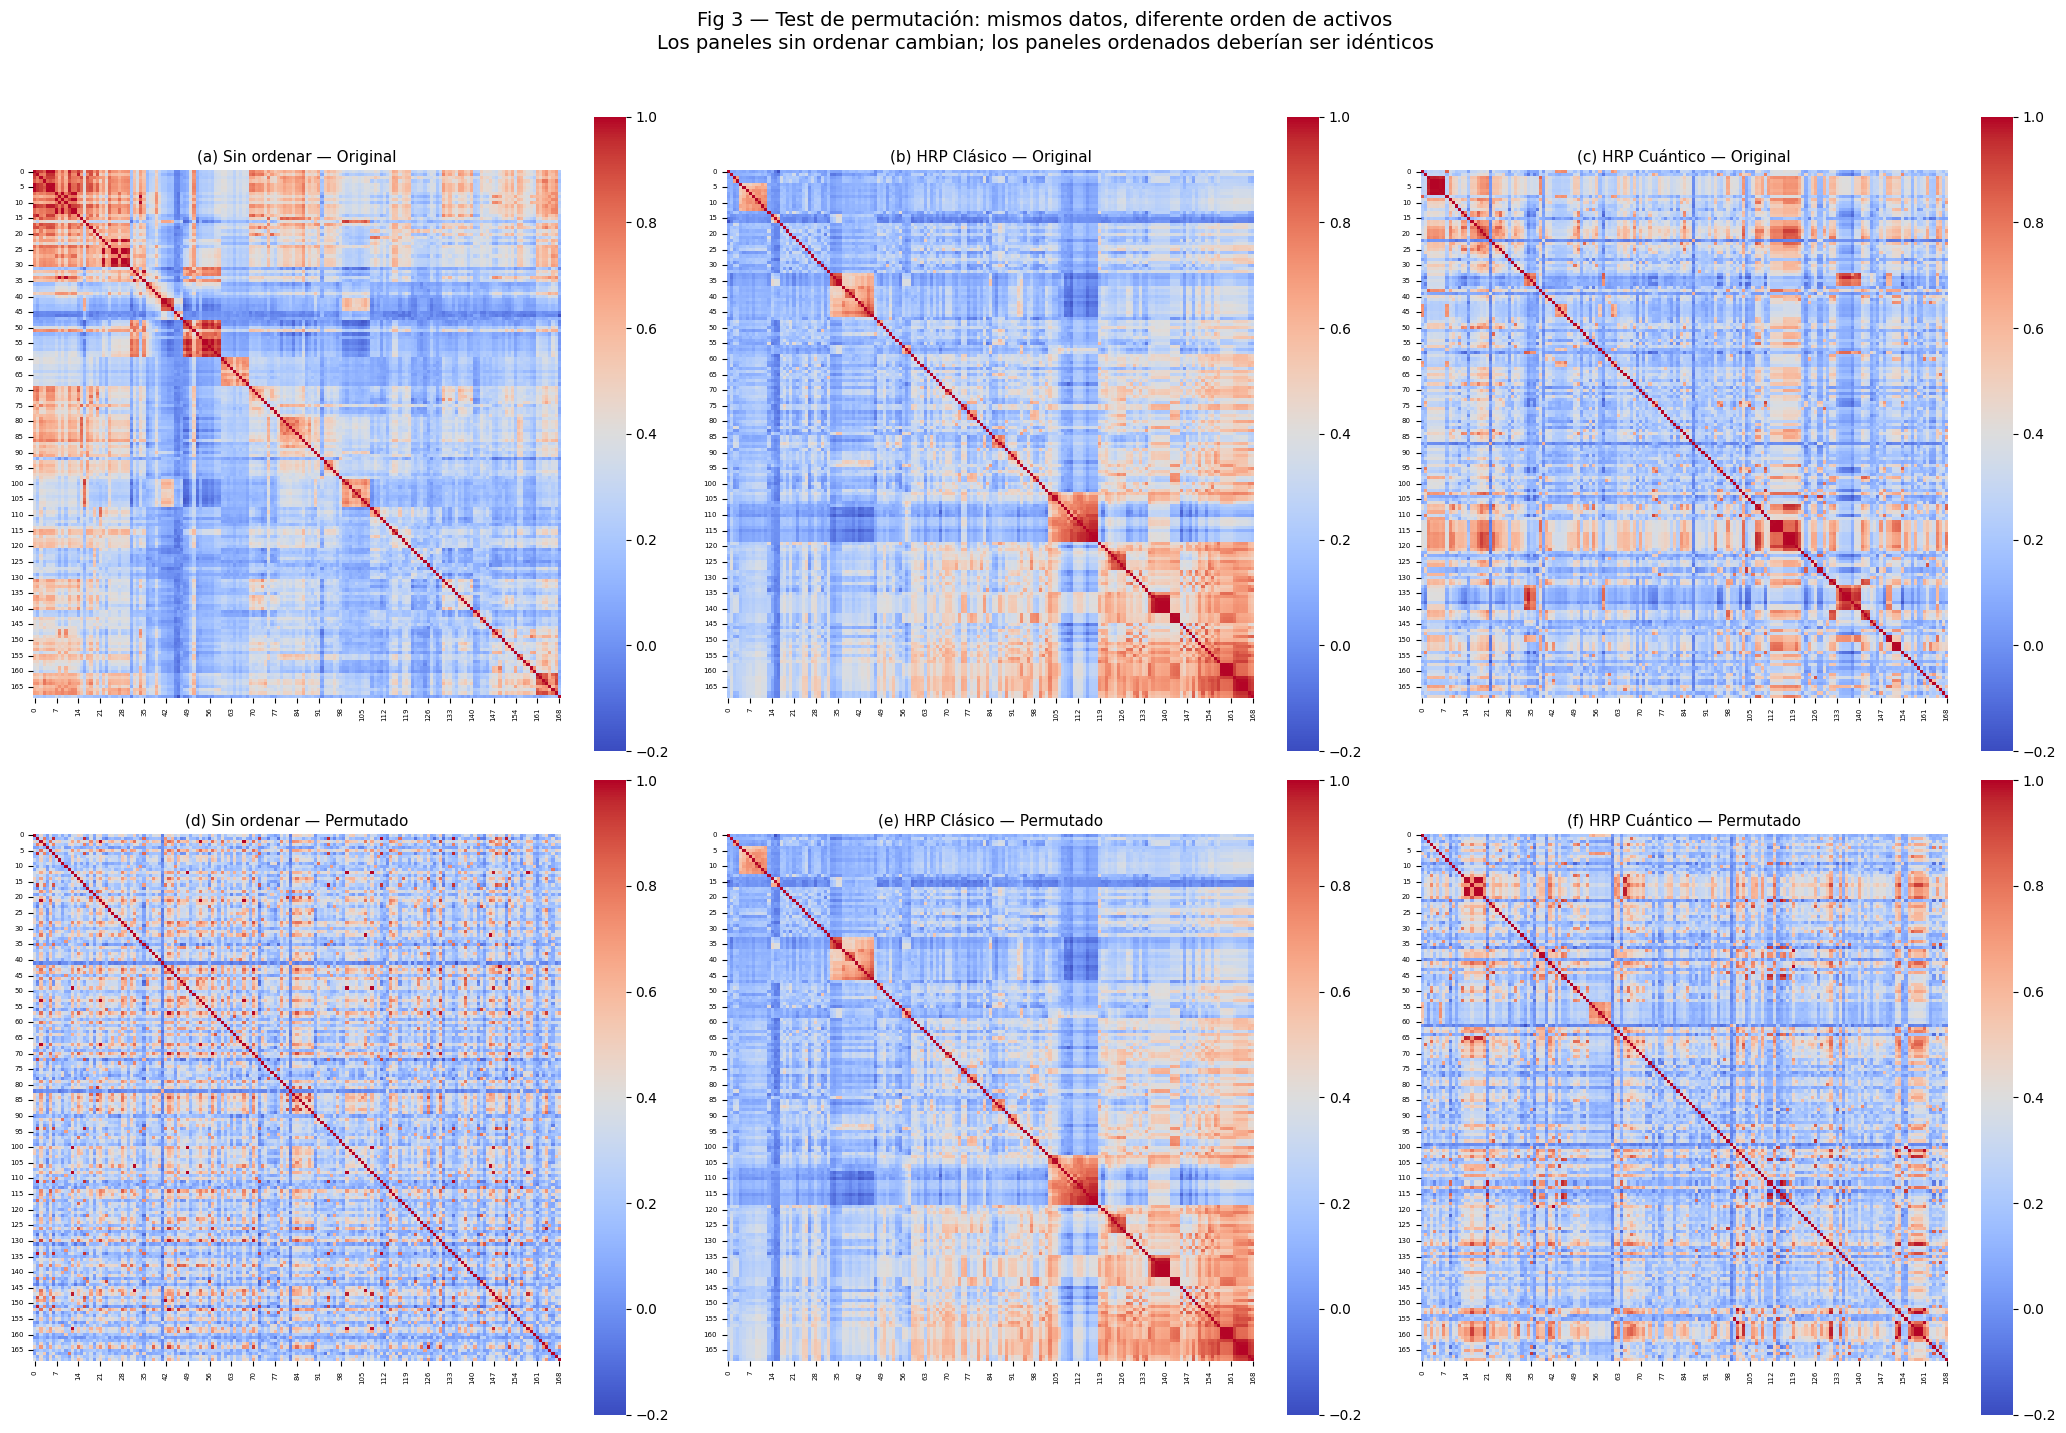

In [17]:
# ── Comparación Fig 3: orden original vs orden permutado ──────────────────
fig, axes = plt.subplots(2, 3, figsize=(21, 14))

titles_top = [
    "(a) Sin ordenar — Original",
    "(b) HRP Clásico — Original",
    "(c) HRP Cuántico — Original",
]
titles_bot = [
    "(d) Sin ordenar — Permutado",
    "(e) HRP Clásico — Permutado",
    "(f) HRP Cuántico — Permutado",
]
mats_top = [corr, corr_classical, corr_quantum]
mats_bot = [corr_shuf, corr_classical_shuf, corr_quantum_shuf]

for col in range(3):
    for row, (mats, titles) in enumerate([(mats_top, titles_top), (mats_bot, titles_bot)]):
        sns.heatmap(
            mats[col], cmap="coolwarm", vmin=-0.2, vmax=1.0,
            square=True, cbar=True, ax=axes[row, col],
        )
        axes[row, col].set_title(titles[col], fontsize=11)
        axes[row, col].tick_params(labelsize=5)

plt.suptitle(
    "Fig 3 — Test de permutación: mismos datos, diferente orden de activos\n"
    "Los paneles sin ordenar cambian; los paneles ordenados deberían ser idénticos",
    fontsize=14, y=1.02,
)
plt.tight_layout()
plt.show()


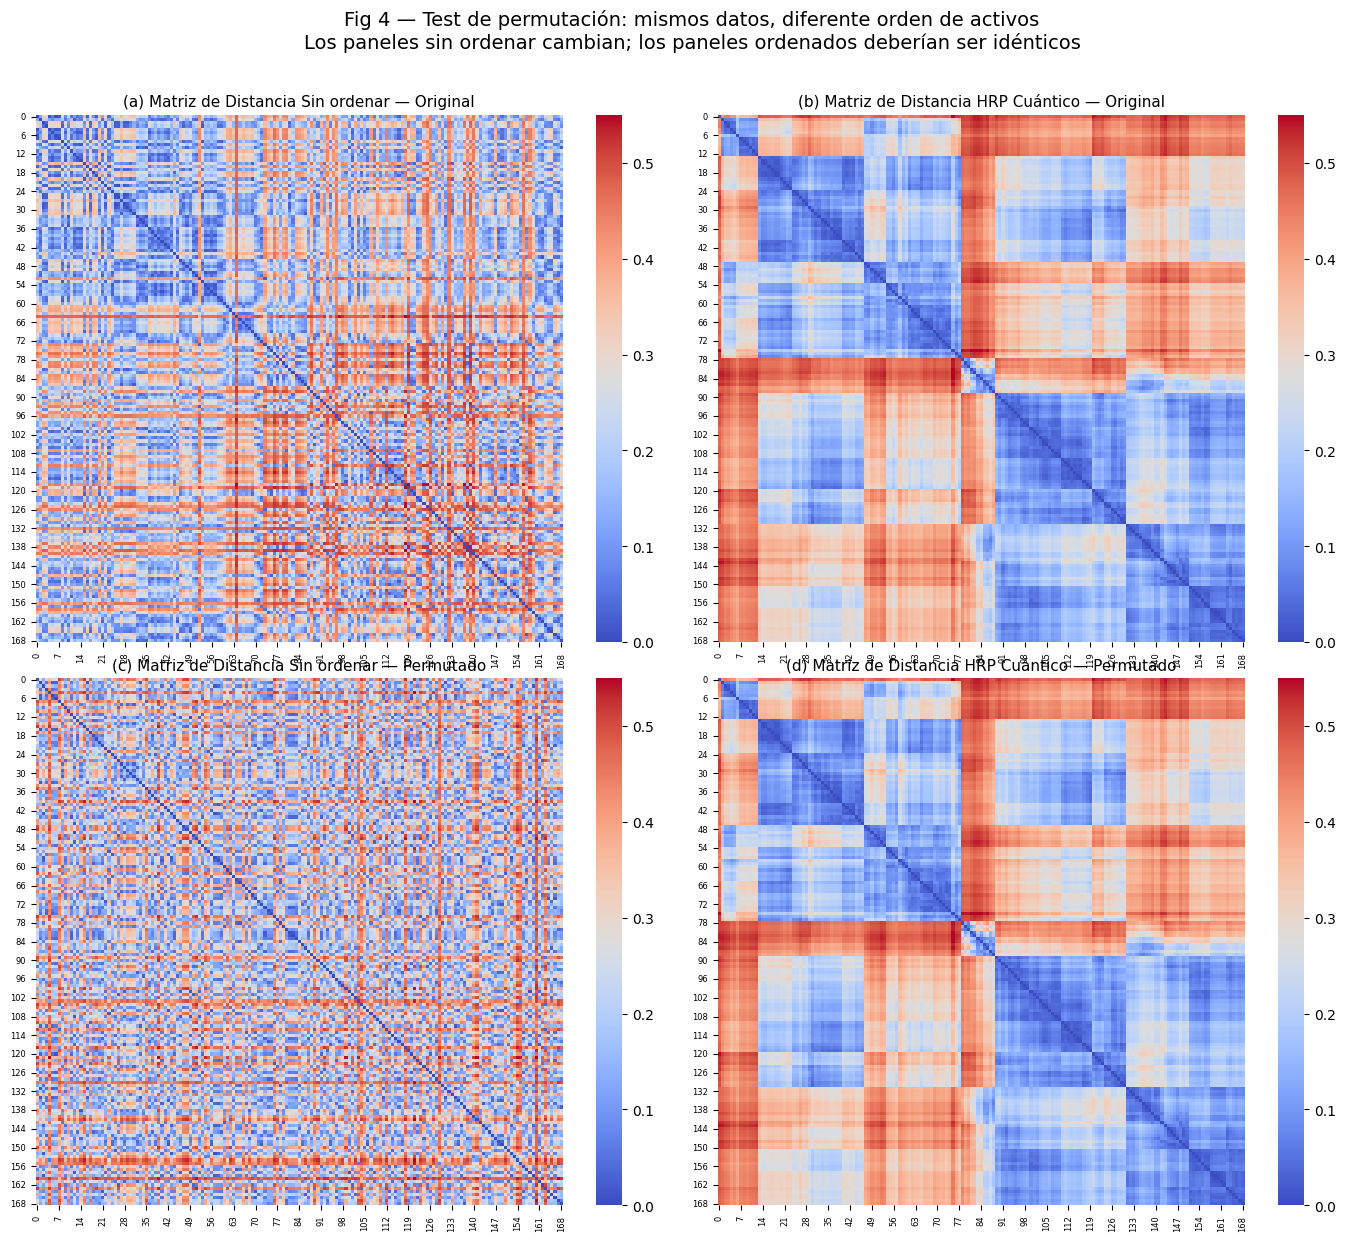

In [18]:
# ── Comparación Fig 4: orden original vs orden permutado ──────────────────
vmax_fig = 0.55

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Fila superior: original
sns.heatmap(D_best, cmap="coolwarm", vmin=0, vmax=vmax_fig,
            square=True, cbar=True, ax=axes[0, 0])
axes[0, 0].set_title("(a) Matriz de Distancia Sin ordenar — Original", fontsize=11)
axes[0, 0].tick_params(labelsize=6)

D_best_ordered_orig = D_best[np.ix_(order_best, order_best)]
sns.heatmap(D_best_ordered_orig, cmap="coolwarm", vmin=0, vmax=vmax_fig,
            square=True, cbar=True, ax=axes[0, 1])
axes[0, 1].set_title("(b) Matriz de Distancia HRP Cuántico — Original", fontsize=11)
axes[0, 1].tick_params(labelsize=6)

# Fila inferior: permutado
sns.heatmap(D_quantum_shuf, cmap="coolwarm", vmin=0, vmax=vmax_fig,
            square=True, cbar=True, ax=axes[1, 0])
axes[1, 0].set_title("(c) Matriz de Distancia Sin ordenar — Permutado", fontsize=11)
axes[1, 0].tick_params(labelsize=6)

sns.heatmap(D_quantum_shuf_ordered, cmap="coolwarm", vmin=0, vmax=vmax_fig,
            square=True, cbar=True, ax=axes[1, 1])
axes[1, 1].set_title("(d) Matriz de Distancia HRP Cuántico — Permutado", fontsize=11)
axes[1, 1].tick_params(labelsize=6)

plt.suptitle(
    "Fig 4 — Test de permutación: mismos datos, diferente orden de activos\n"
    "Los paneles sin ordenar cambian; los paneles ordenados deberían ser idénticos",
    fontsize=14, y=1.02,
)
plt.tight_layout()
plt.show()


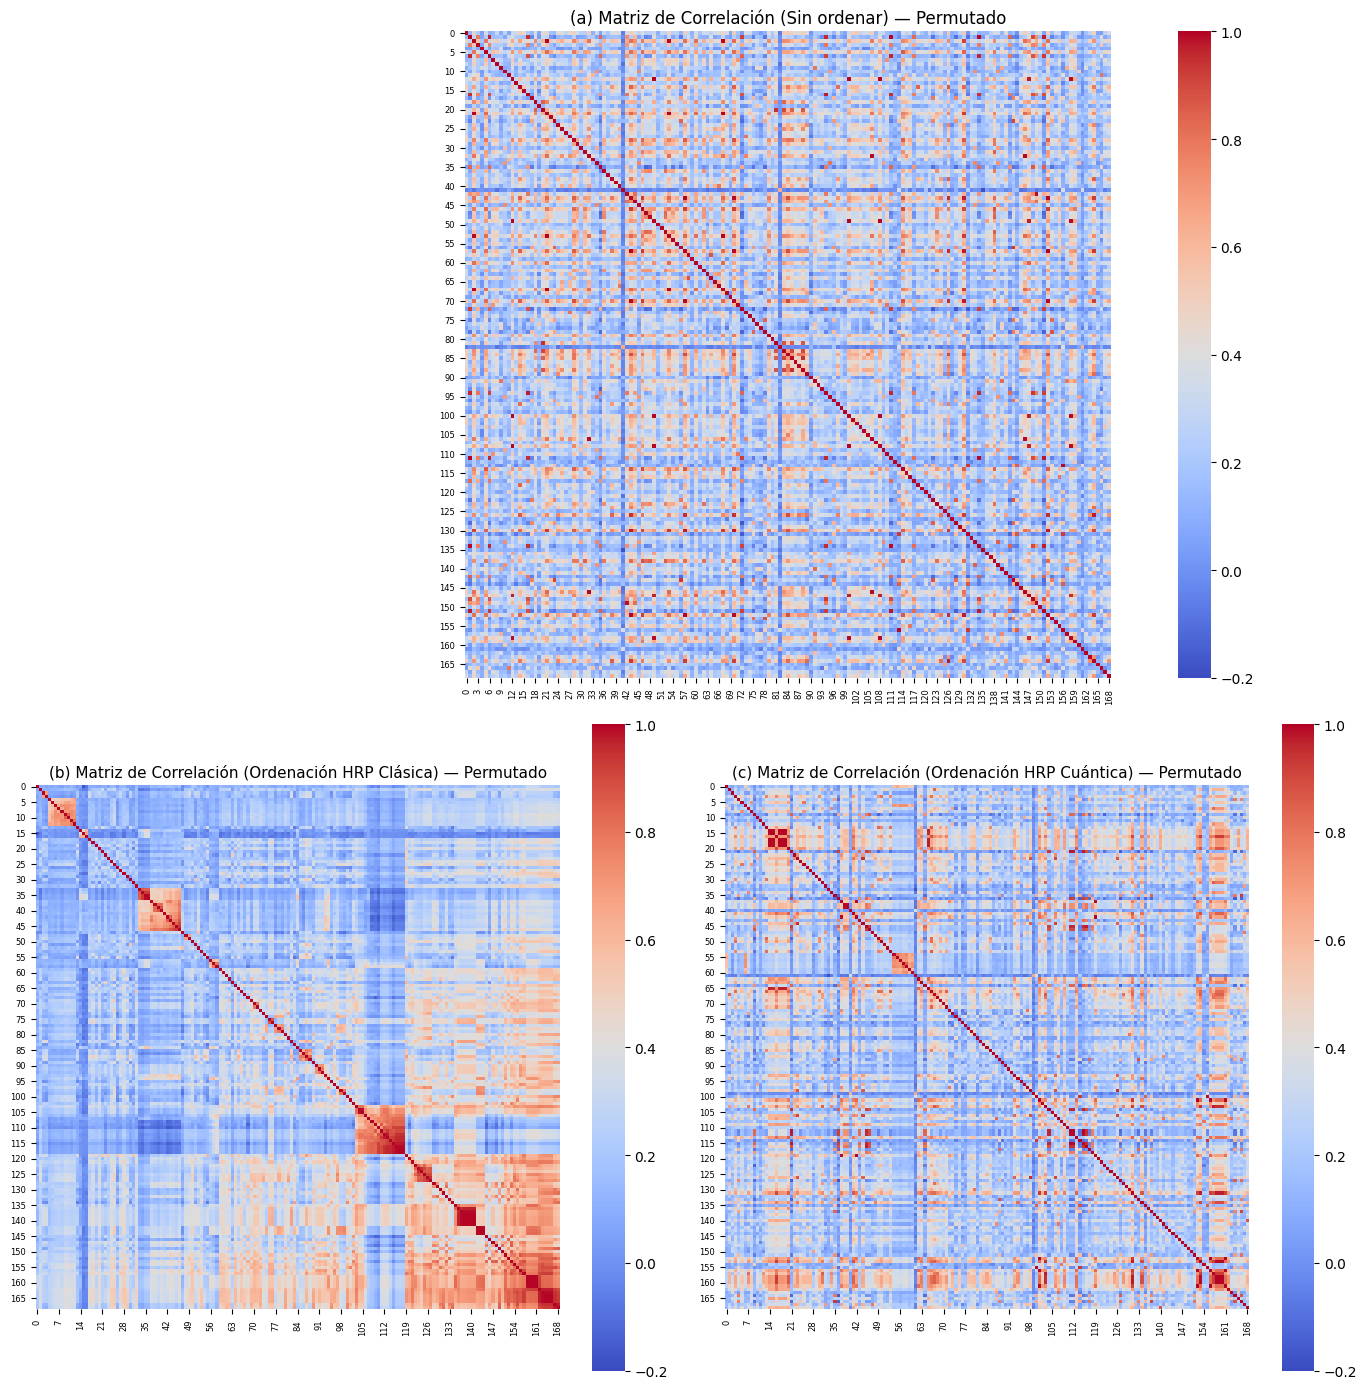

In [19]:
# ── Fig 3 — Permutado (independiente) ──────────────────────────────────────
fig = plt.figure(figsize=(14, 14))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1])

# ---------- (a) Sin ordenar — Permutado ----------
ax0 = fig.add_subplot(gs[0, :])
sns.heatmap(
    corr_shuf,
    cmap="coolwarm",
    vmin=-0.2,
    vmax=1.0,
    square=True,
    cbar=True,
    ax=ax0
)
ax0.set_title("(a) Matriz de Correlación (Sin ordenar) — Permutado", fontsize=12)
ax0.tick_params(labelsize=6)

# ---------- (b) HRP Clásico — Permutado ----------
ax1 = fig.add_subplot(gs[1, 0])
sns.heatmap(
    corr_classical_shuf,
    cmap="coolwarm",
    vmin=-0.2,
    vmax=1.0,
    square=True,
    cbar=True,
    ax=ax1
)
ax1.set_title("(b) Matriz de Correlación (Ordenación HRP Clásica) — Permutado", fontsize=11)
ax1.tick_params(labelsize=6)

# ---------- (c) HRP Cuántico — Permutado ----------
ax2 = fig.add_subplot(gs[1, 1])
sns.heatmap(
    corr_quantum_shuf,
    cmap="coolwarm",
    vmin=-0.2,
    vmax=1.0,
    square=True,
    cbar=True,
    ax=ax2
)
ax2.set_title("(c) Matriz de Correlación (Ordenación HRP Cuántica) — Permutado", fontsize=11)
ax2.tick_params(labelsize=6)

plt.tight_layout()
fig.savefig(os.path.join(out_dir, "fig3-shuffled.png"), dpi=300, bbox_inches="tight")
fig.savefig(os.path.join(out_dir, "fig3-shuffled.pdf"), bbox_inches="tight")
plt.show()


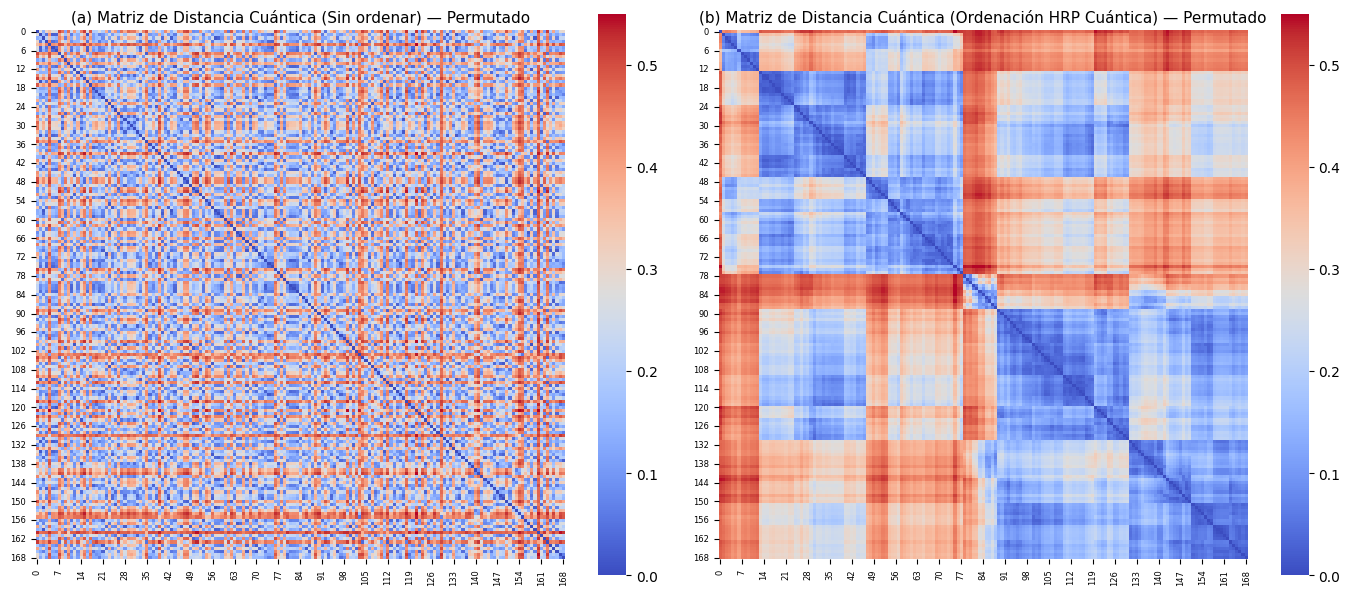

In [20]:
# ── Fig 4 — Permutado (independiente) ──────────────────────────────────────
vmax_fig = 0.55

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(D_quantum_shuf, cmap="coolwarm", vmin=0, vmax=vmax_fig,
            square=True, cbar=True, ax=axes[0])
axes[0].set_title("(a) Matriz de Distancia Cuántica (Sin ordenar) — Permutado", fontsize=11)
axes[0].tick_params(labelsize=6)

sns.heatmap(D_quantum_shuf_ordered, cmap="coolwarm", vmin=0, vmax=vmax_fig,
            square=True, cbar=True, ax=axes[1])
axes[1].set_title("(b) Matriz de Distancia Cuántica (Ordenación HRP Cuántica) — Permutado", fontsize=11)
axes[1].tick_params(labelsize=6)

plt.tight_layout()
fig.savefig(os.path.join(out_dir, "fig4-shuffled.png"), dpi=300, bbox_inches="tight")
fig.savefig(os.path.join(out_dir, "fig4-shuffled.pdf"), bbox_inches="tight")
plt.show()
